# Visualize the UMAP coordinates of Cell Painting profiles

The UMAP coordinates were derived in `10.crispr-umap.ipynb`. Generate a supplementary figure here.

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(cowplot))

source(file.path("scripts", "assay_themes.R"))

In [2]:
consensus <- "modz"
results_dir <- file.path("results")
shiny_app_dir <- file.path("..", "4.apply", "repurposing_cellhealth_shiny", "data")

output_figure_file <- file.path(
    "figures", "summary", "crispr_umap_supplementary_figure.png"
)

point_alpha <- 0.7
point_size <- 0.8
axis_text_size <- 7.5
legend_text_size <- 7

text_theme <- theme(
    axis.title = element_text(size = axis_text_size),
    legend.title = element_text(size = legend_text_size),
    legend.text = element_text(size = legend_text_size)
)

umap_file <- file.path(
    shiny_app_dir, paste0("profile_umap_with_cell_health_", consensus, ".tsv")
)
umap_df <- readr::read_tsv(umap_file, col_types = readr::cols())

print(dim(umap_df))
head(umap_df, 3)
# VALIDATION: Check if we have sufficient data for visualization
if (nrow(umap_df) == 0) {
    stop("ERROR: UMAP data is empty. Cannot proceed with visualization.")
}

# Check if required columns exist
required_cols <- c("umap_x", "umap_y", "Metadata_cell_line", "cc_g1_n_objects", "vb_ros_mean")
missing_cols <- required_cols[!required_cols %in% colnames(umap_df)]
if (length(missing_cols) > 0) {
    stop("ERROR: Missing required columns: ", paste(missing_cols, collapse = ", "))
}

# Check if we have enough data for meaningful visualization
if (nrow(umap_df) < 5) {
    cat("WARNING: Very limited data (", nrow(umap_df), " rows). Visualizations may be sparse.\n")
}

# Check cell line diversity
cell_line_counts <- table(umap_df$Metadata_cell_line)
if (length(cell_line_counts) < 2) {
    cat("WARNING: Limited cell line diversity (", length(cell_line_counts), " cell lines).\n")
    cat("Available cell lines:", paste(names(cell_line_counts), collapse = ", "), "\n")
}

cat("Data validation passed. Proceeding with visualization.\n")


[1] 119  86


umap_x,umap_y,index,cell_id,guide,cc_all_high_h2ax,cc_all_large_notround_polynuclear_mean,cc_all_large_round_polyploid_mean,cc_all_n_objects,cc_all_n_spots_h2ax_mean,⋯,Metadata_pert_name,Metadata_cell_line,Metadata_gene_name,Metadata_broad_sample,Metadata_cell_process,Metadata_cell_health_data,Metadata_cell_painting_data,Metadata_A549_ctg_efficiency,Metadata_ES2_ctg_efficiency,Metadata_HCC44_ctg_efficiency
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>
5.825033,3.738619,0,A549,AKT1-1,-0.005795126,0.5803515,0.01397514,0.3819577,0.1506965,⋯,AKT1-1,A549,AKT1,BRDN0001054908,PIK3CA,TRUE,TRUE,0.9196904,1.0572268,1.0226697
5.372091,3.592877,1,A549,AKT1-2,0.050169440,1.2777304,0.24180835,0.5774218,0.2208285,⋯,AKT1-2,A549,AKT1,BRDN0001055115,PIK3CA,TRUE,TRUE,0.8420403,0.9570052,0.9300254
6.246626,4.871582,10,A549,BCL2-2,-0.182172368,0.2702535,-0.16533465,1.0220810,-0.4430777,⋯,BCL2-2,A549,BCL2,NA,Apoptosis,TRUE,TRUE,0.8453073,1.1374569,1.1601808


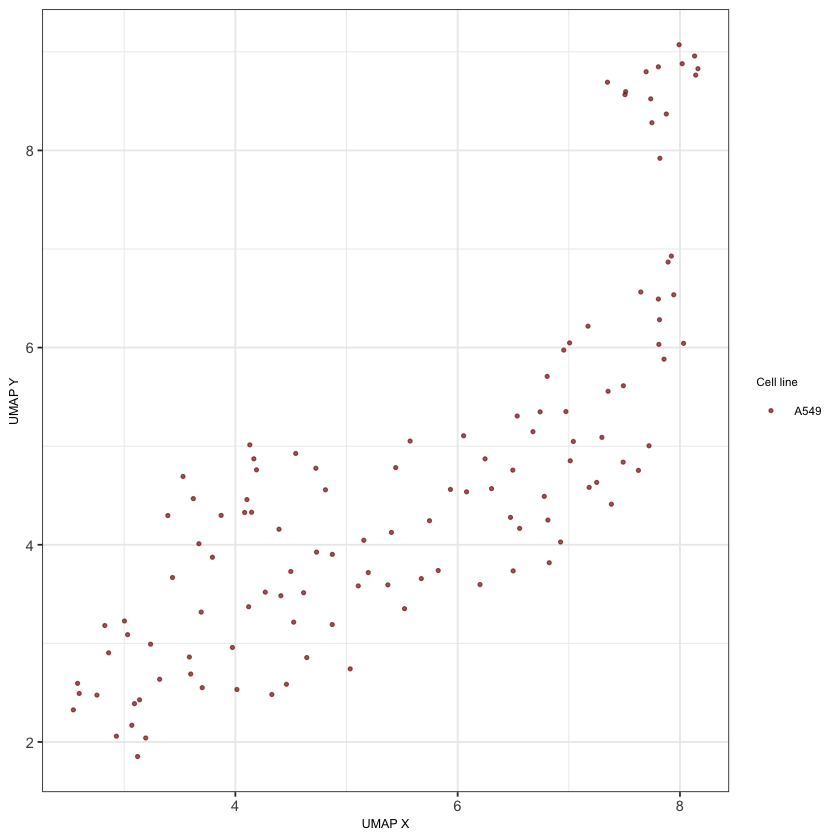

In [3]:
  cell_line_gg
}, error = function(e) {
  cat("Error creating cell line plot:", e$message, "\n")
  cat("Skipping this visualization due to data issues\n")
  return(NULL)
}) <- tryCatch({
  ggplot(umap_df, aes(x = umap_x, y = umap_y)) +
    geom_point(aes(color = Metadata_cell_line), alpha = point_alpha, size = point_size) +
    xlab("UMAP X") +
    ylab("UMAP Y") +
    scale_color_manual(
        name = "Cell line",
        values = cell_line_colors,
        labels = cell_line_labels
    ) +
    theme_bw() +
    text_theme


  cell_line_gg
}, error = function(e) {
  cat("Error creating cell line plot:", e$message, "\n")
  cat("Skipping this visualization due to data issues\n")
  return(NULL)
})

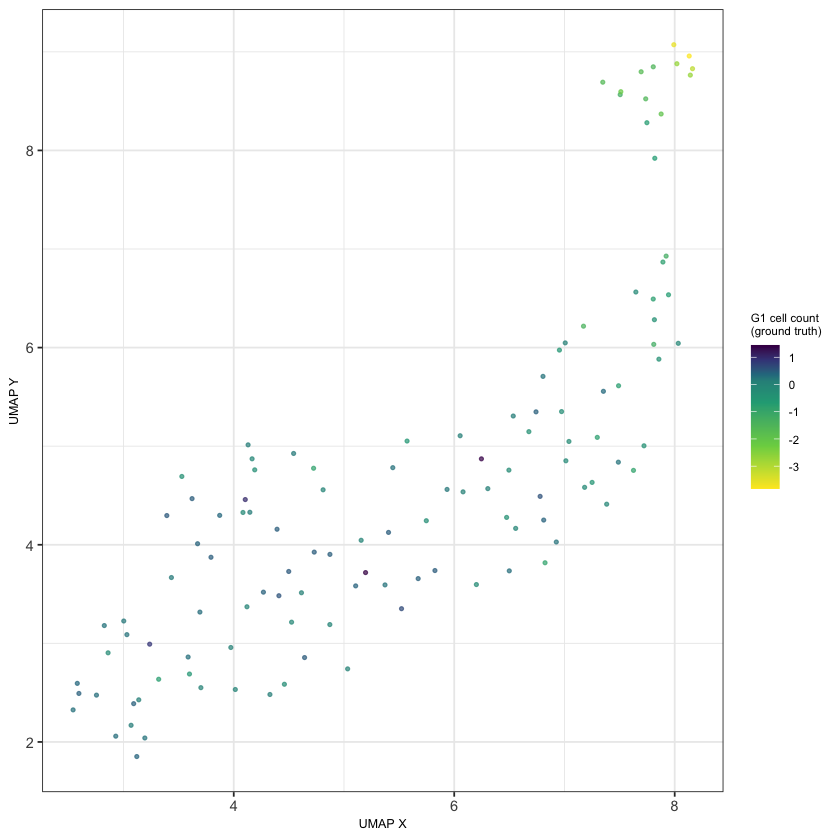

In [4]:
g1_count_gg <- ggplot(umap_df, aes(x = umap_x, y = umap_y)) +
    geom_point(aes(color = cc_g1_n_objects), alpha = point_alpha, size = point_size) +
    xlab("UMAP X") +
    ylab("UMAP Y") +
    theme_bw() +
    text_theme +
    scale_color_viridis_c(
        name = "G1 cell count\n(ground truth)",
        values = scales::rescale(c(1, 0.8, 0.2))
    )

g1_count_gg

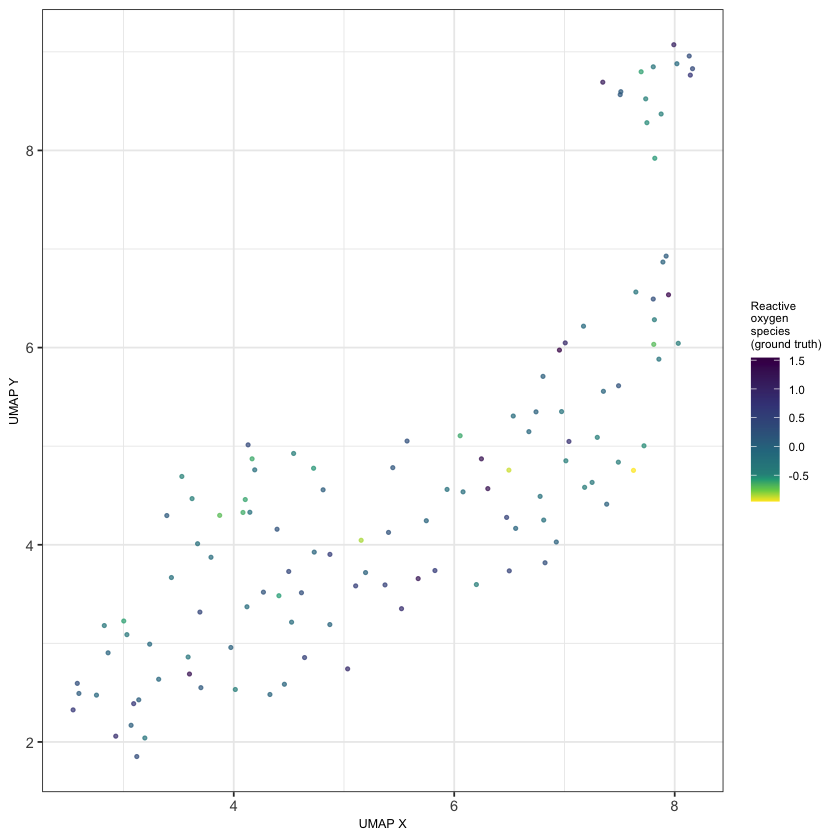

In [5]:
ros_gg <- ggplot(umap_df, aes(x = umap_x, y = umap_y)) +
    geom_point(aes(color = vb_ros_mean), alpha = point_alpha, size = point_size) +
    xlab("UMAP X") +
    ylab("UMAP Y") +
    theme_bw() +
    text_theme +
    scale_color_viridis_c(
        name = "Reactive\noxygen\nspecies\n(ground truth)",
        values = scales::rescale(c(10, 3.5, 2))
    )

ros_gg

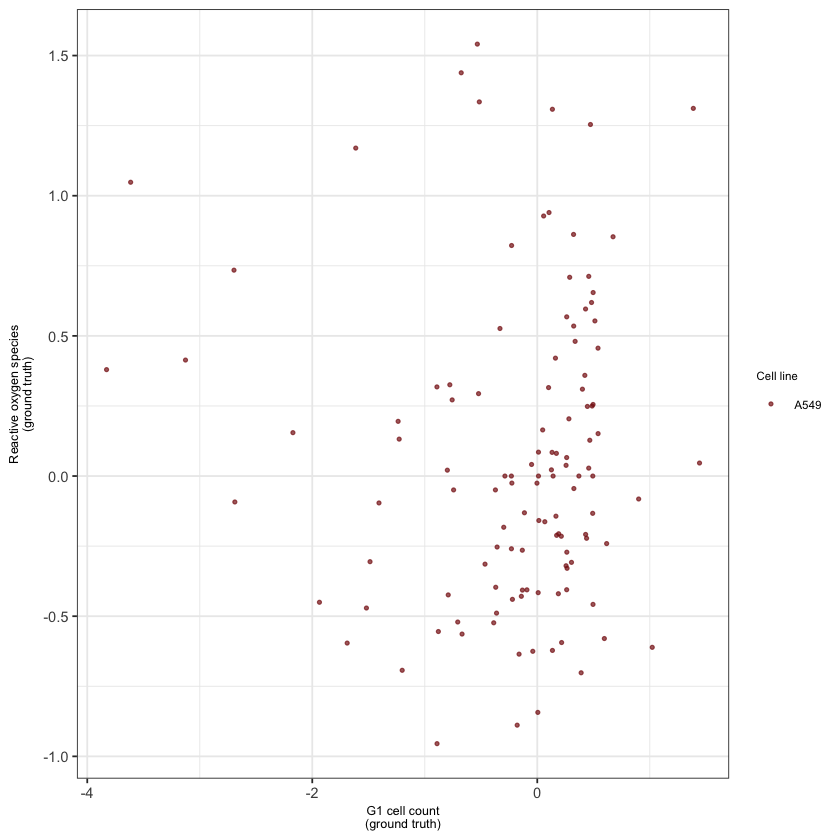

In [6]:
scatter_gg <- ggplot(umap_df, aes(x = cc_g1_n_objects, y = vb_ros_mean)) +
    geom_point(aes(color = Metadata_cell_line), alpha = point_alpha, size = point_size) +
    xlab("G1 cell count\n(ground truth)") +
    ylab("Reactive oxygen species\n(ground truth)") +
    theme_bw() +
    text_theme +
    scale_color_manual(
        name = "Cell line",
        values = cell_line_colors,
        labels = cell_line_labels
    )

scatter_gg

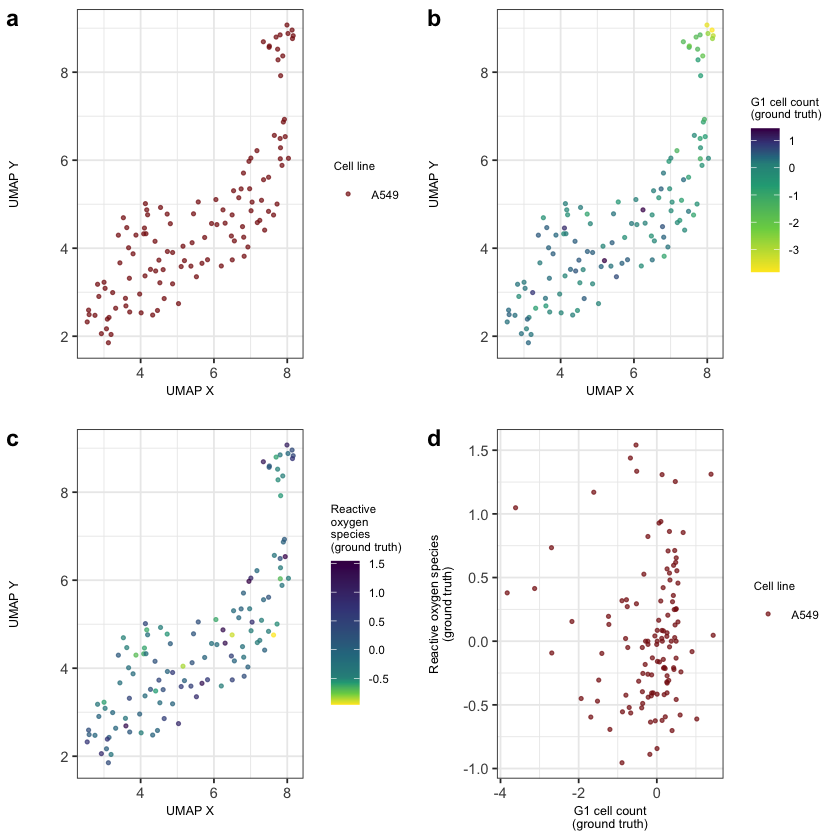

In [7]:
# Create multiplot
full_figure <- cowplot::plot_grid(
    cell_line_gg,
    g1_count_gg,
    ros_gg,
    scatter_gg,
    labels = c("a", "b", "c", "d"),
    align = "hv",
    nrow = 2
)

cowplot::save_plot(
    filename = output_figure_file,
    plot = full_figure,
    dpi = 500,
    base_width = 7,
    base_height = 5
)

full_figure